# Pipeline de clasificacion de sentimiento

El flujo descarga resenas binarias desde Kaggle, transforma el texto con TF-IDF y clasifica cada resena con `LinearSVC`. Las etiquetas son `negative` y `positive`.

In [33]:
import shutil
import subprocess

nvidia_smi = shutil.which('nvidia-smi')
# Check if GPU is available
if nvidia_smi:
    print(subprocess.run([nvidia_smi], capture_output=True, text=True, check=False).stdout)
else:
    print('No se encontro nvidia-smi; se usara CPU.')

Mon Sep  7 13:55:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.99                 Driver Version: 555.99         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   41C    P8             11W /   65W |    3217MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [34]:
try:
    import sklearn
except ImportError as error:
    raise ImportError('Instala scikit-learn con `pip install scikit-learn` antes de continuar.') from error

In [35]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Datos

In [36]:
# Load the cleaned dataset
reviews = pd.read_csv('cleaned_reviews.csv')

## 2. Entrenamiento y evaluacion

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    reviews['text'],
    reviews['label'],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=reviews['label'],
)

sentiment_model = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=1, sublinear_tf=True)),
    ('classifier', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)),
])
sentiment_model.fit(X_train, y_train)
predictions = sentiment_model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, predictions):.3f}')
print(classification_report(y_test, predictions, labels=['negative', 'positive'], zero_division=0))

Accuracy: 0.915
              precision    recall  f1-score   support

    negative       0.93      0.90      0.91      3963
    positive       0.90      0.93      0.92      3982

    accuracy                           0.91      7945
   macro avg       0.91      0.91      0.91      7945
weighted avg       0.91      0.91      0.91      7945



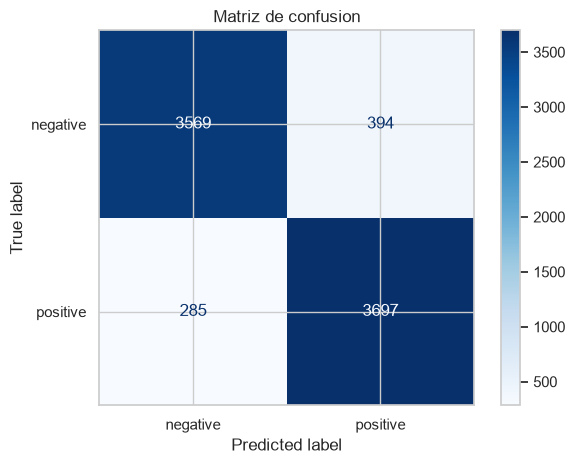

In [38]:
labels = ['negative', 'positive']
matrix = confusion_matrix(y_test, predictions, labels=labels)
ConfusionMatrixDisplay(matrix, display_labels=labels).plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusion')
plt.tight_layout()
plt.show()

## 3. Prediccion de nuevas reseñas

In [39]:
new_reviews = [
    'The movie had brilliant performances and I loved every minute.',
    'It was acceptable, but there was nothing memorable about it.',
    'The package was damaged and the product did not work.',
]
pd.DataFrame({'review': new_reviews, 'predicted_sentiment': sentiment_model.predict(new_reviews)})

,review,predicted_sentiment
0,The movie had brilliant performances and I lov...,positive
1,"It was acceptable, but there was nothing memor...",negative
2,The package was damaged and the product did no...,negative


## 4. Mejoras y futuro trabajo

- Comparar hiperparametros con validacion cruzada y grid search.
- Comparar con otros modelos de clasificacion, como `LogisticRegression`, `RandomForestClassifier` o `XGBClassifier`.
- Comparar con modelos de lenguaje preentrenados como DistilBERT, BERT o RoBERTa, que pueden capturar mejor el contexto y la semantica del texto.